<font size=8> Tiny CNN For Human Face Detector </font>

----

**Note:** We trained our CNN on Region of Interest (ROI) patches extracted using Haar Cascades. We used the LFW dataset for face mining and the PASS dataset for non-face mining. All detected ROIs were grouped, resized to 34x34, and enhanced via data augmentation. For instructions on generating your own train/val/test splits, please refer to the dataset_mining.ipynb document.

In [1]:
# Install dependencies
!pip install opencv-python matplotlib tqdm numpy 

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\Jalal\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
# Imports
import cv2
import os
import glob
import random
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from collections import defaultdict
from tqdm import tqdm

# Check versions
print(f"OpenCV version: {cv2.__version__}")
print(f"Matplotlib version: {matplotlib.__version__}")
print(f"NumPy version: {np.__version__}")
print("All packages installed successfully")

OpenCV version: 4.13.0
Matplotlib version: 3.10.8
NumPy version: 2.4.2
All packages installed successfully


# Training set visualization:

**Faces:**

Found 4900 training face images


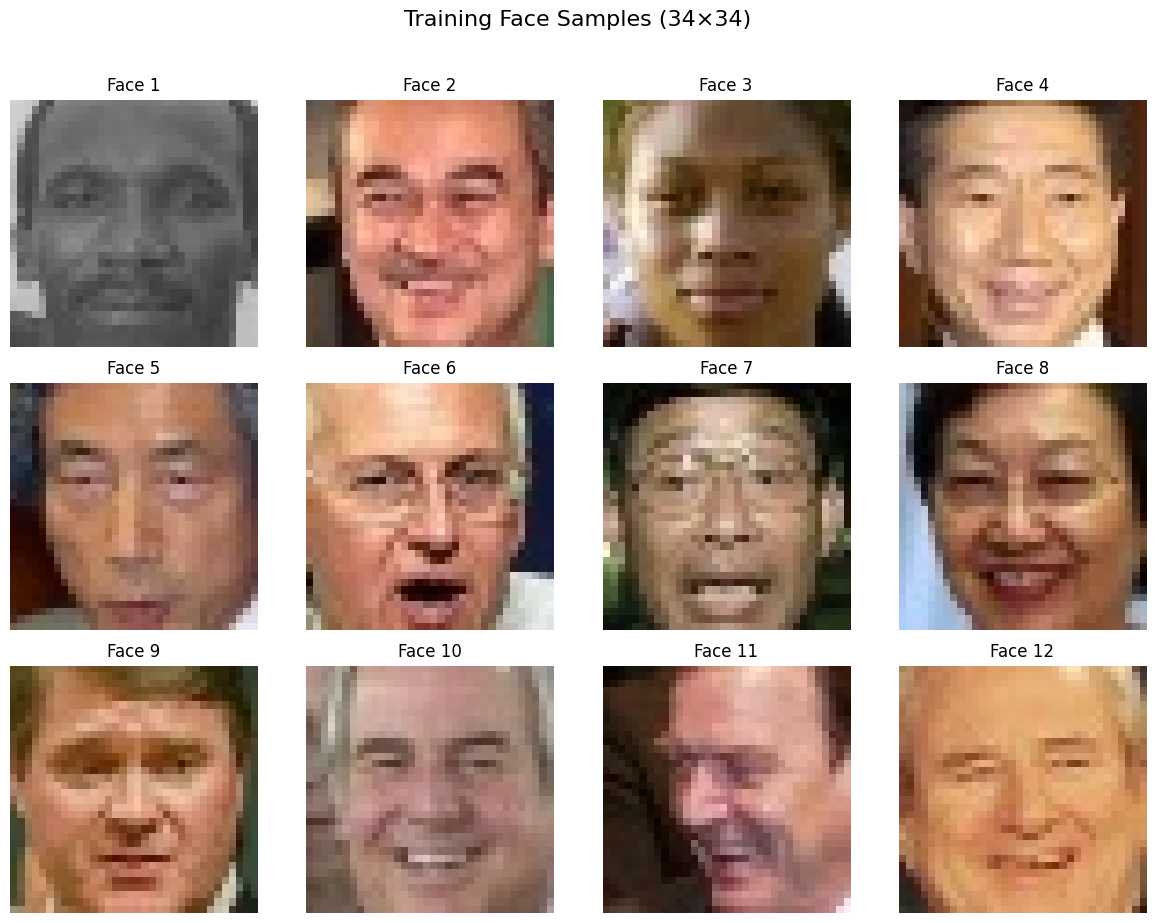


 Training Face Statistics:
Total training faces: 4900
Image size: 34×34 pixels
Showing 12 random samples


In [8]:
NUM_SAMPLES = 12  # Number of face samples to show
DATASET_ROOT = "../dataset"
# Path to training faces
faces_dir = os.path.join(DATASET_ROOT, "train", "faces")

# Check if path exists
if not os.path.exists(faces_dir):
    print(f"ERROR: Training faces directory not found at: {faces_dir}")
    print("Please check your DATASET_ROOT path.")
else:
    # Get all face files
    face_files = [f for f in os.listdir(faces_dir) if f.endswith(".jpg")]

    if not face_files:
        print("No face images found in training set!")
    else:
        print(f"Found {len(face_files)} training face images")

        # Randomly select samples
        num_to_show = min(NUM_SAMPLES, len(face_files))
        selected = random.sample(face_files, num_to_show)

        # Create figure
        rows = (num_to_show + 3) // 4  # Calculate rows needed (4 columns)
        cols = min(4, num_to_show)

        fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))

        # Handle single subplot case
        if rows == 1 and cols == 1:
            axes = np.array([[axes]])
        elif rows == 1:
            axes = axes.reshape(1, -1)
        elif cols == 1:
            axes = axes.reshape(-1, 1)

        # Display each sample
        for i, f in enumerate(selected):
            row = i // cols
            col = i % cols

            img_path = os.path.join(faces_dir, f)
            img = cv2.imread(img_path)

            if img is not None:
                img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                axes[row, col].imshow(img_rgb)
                axes[row, col].set_title(f"Face {i+1}")
            else:
                axes[row, col].set_title(f"Error loading {f}")

            axes[row, col].axis("off")

        # Hide empty subplots
        for i in range(num_to_show, rows * cols):
            row = i // cols
            col = i % cols
            axes[row, col].axis("off")

        plt.suptitle(f"Training Face Samples (34×34)", fontsize=16, y=1.02)
        plt.tight_layout()
        plt.show()

        # Print statistics
        print("\n Training Face Statistics:")
        print(f"Total training faces: {len(face_files)}")
        print(f"Image size: 34×34 pixels")
        print(f"Showing {num_to_show} random samples")

**Nonfaces:**

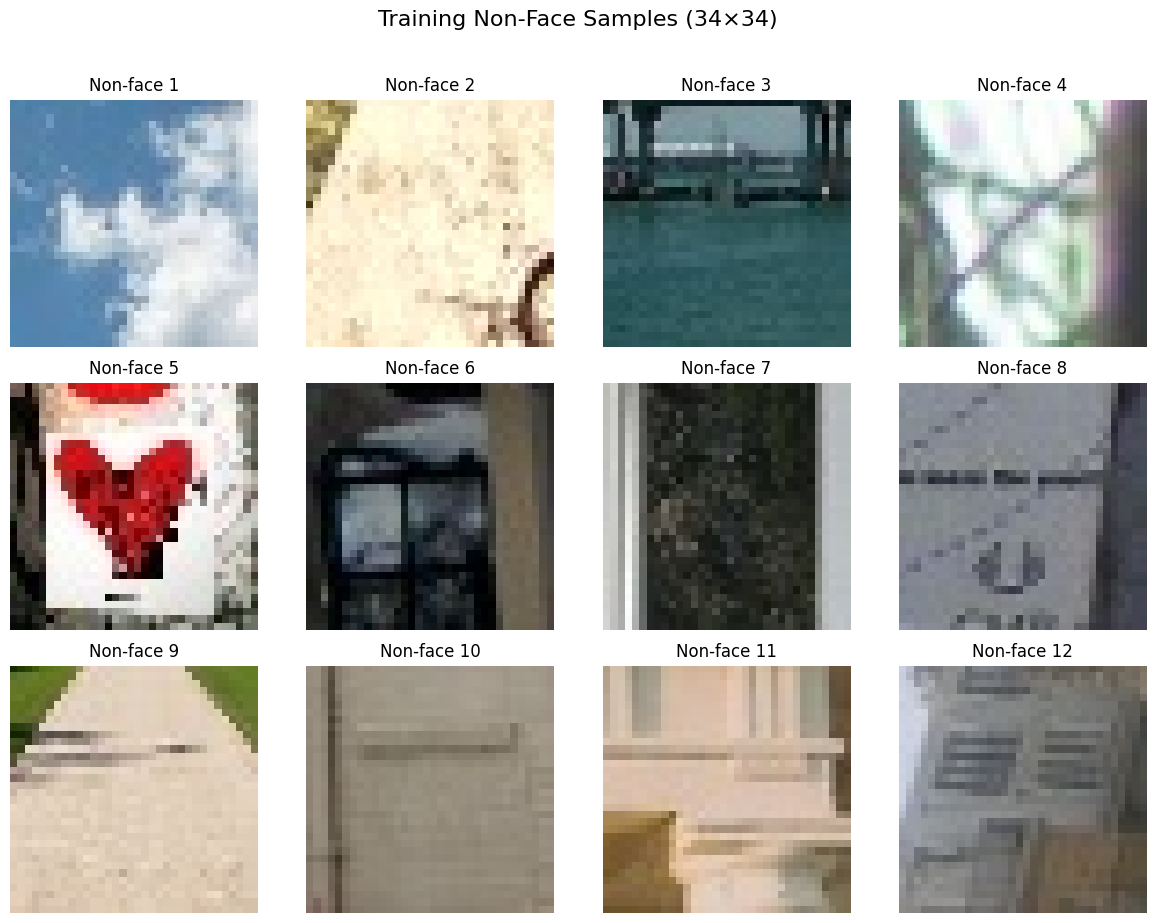


Training Non-Face Statistics:
Total training non-faces: 4200
  - Hard negatives (Haar false positives): 4200
  - Augmented versions: 0
Image size: 34×34 pixels


In [ ]:
NUM_SAMPLES = 12  # Number of non-face samples to show

# Path to training non-faces
nonfaces_dir = os.path.join(DATASET_ROOT, "train", "nonfaces")

# Check if path exists
if not os.path.exists(nonfaces_dir):
    print(f"ERROR: Training non-faces directory not found at: {nonfaces_dir}")
    print("Please check your DATASET_ROOT path.")
else:
    # Get all non-face files
    nonface_files = [f for f in os.listdir(nonfaces_dir) if f.endswith(".jpg")]

    if not nonface_files:
        print("No non-face images found in training set!")
    else:
        # Separate hard negatives (original) vs augmented
        hard_files = [f for f in nonface_files if "nonface_" in f and "aug" not in f]
        aug_files = [f for f in nonface_files if "aug" in f]

        # Randomly select samples to display
        num_to_show = min(NUM_SAMPLES, len(nonface_files))
        selected = random.sample(nonface_files, num_to_show)

        # Create figure
        rows = (num_to_show + 3) // 4  # Calculate rows needed (4 columns)
        cols = min(4, num_to_show)

        fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))

        # Handle single subplot case
        if rows == 1 and cols == 1:
            axes = np.array([[axes]])
        elif rows == 1:
            axes = axes.reshape(1, -1)
        elif cols == 1:
            axes = axes.reshape(-1, 1)

        # Display each sample
        for i, f in enumerate(selected):
            row = i // cols
            col = i % cols

            img_path = os.path.join(nonfaces_dir, f)
            img = cv2.imread(img_path)

            if img is not None:
                img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                axes[row, col].imshow(img_rgb)
                axes[row, col].set_title(f"Non-face {i+1}")

                   
            else:
                axes[row, col].set_title(f"Error")

            axes[row, col].axis("off")

        # Hide empty subplots
        for i in range(num_to_show, rows * cols):
            row = i // cols
            col = i % cols
            axes[row, col].axis("off")

        plt.suptitle(f"Training Non-Face Samples (34×34)", fontsize=16, y=1.02)
        plt.tight_layout()
        plt.show()

        # Print statistics
        print("\nTraining Non-Face Statistics:")
        print(f"Total training non-faces: {len(nonface_files)}")
        print(f"  - Hard negatives (Haar false positives): {len(hard_files)}")
        print(f"Image size: 34×34 pixels")